In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.datasets import load_iris

In [3]:
iris=load_iris()

In [9]:
X=pd.DataFrame(iris['data'],columns=['sepal length in cm','sepal width','petal length','petal width'])

In [10]:
y=iris['target']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22)

In [16]:
from sklearn.tree import DecisionTreeClassifier
treeclassiier=DecisionTreeClassifier(max_depth=2)

In [17]:
treeclassiier.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

[Text(465.0, 641.6666666666666, 'X[2] <= 2.45\ngini = 0.664\nsamples = 120\nvalue = [44, 40, 36]'),
 Text(232.5, 385.0, 'gini = 0.0\nsamples = 44\nvalue = [44, 0, 0]'),
 Text(697.5, 385.0, 'X[3] <= 1.75\ngini = 0.499\nsamples = 76\nvalue = [0, 40, 36]'),
 Text(465.0, 128.33333333333326, 'gini = 0.133\nsamples = 42\nvalue = [0, 39, 3]'),
 Text(930.0, 128.33333333333326, 'gini = 0.057\nsamples = 34\nvalue = [0, 1, 33]')]

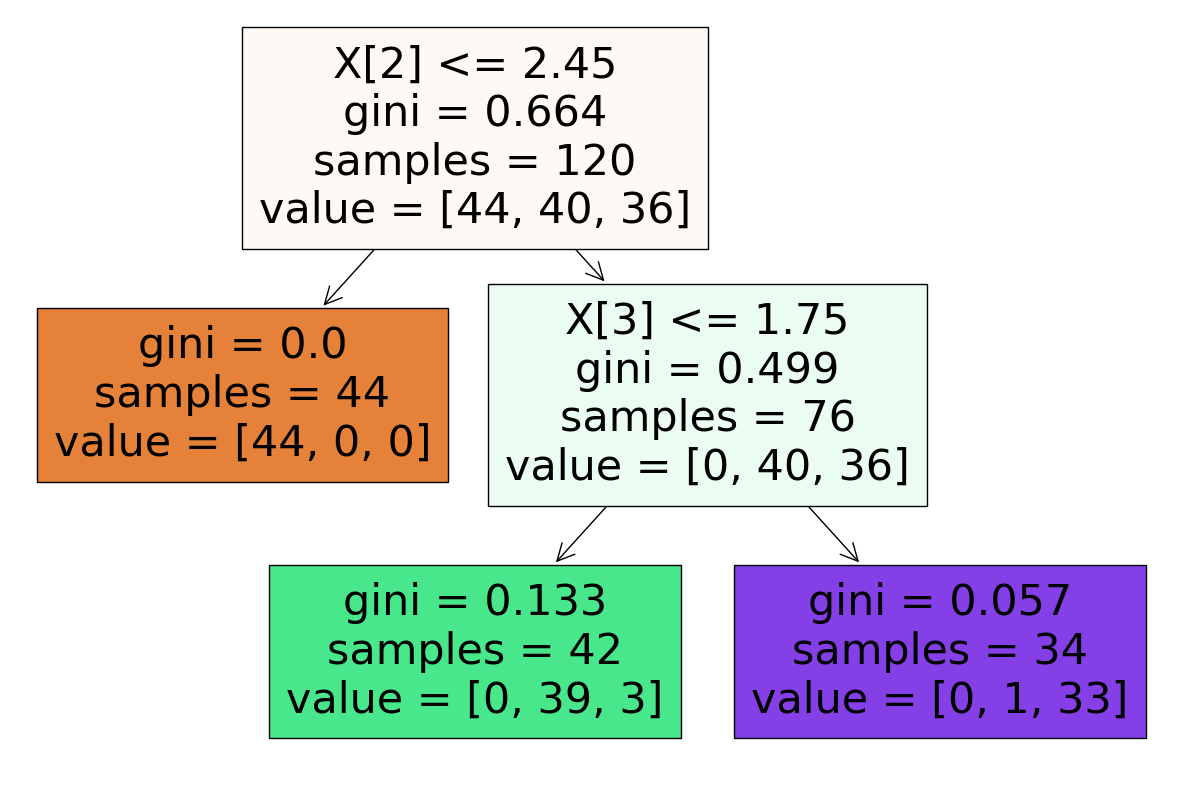

In [18]:
from sklearn import tree 
plt.figure(figsize=(15,10))
tree.plot_tree(treeclassiier,filled=True)

In [20]:
y_pred=treeclassiier.predict(X_train)

In [21]:
from sklearn.metrics import confusion_matrix , classification_report

In [29]:
cm=confusion_matrix(y_train,y_pred)
print(cm)
print(classification_report(y_train,y_pred))

[[44  0  0]
 [ 0 37  3]
 [ 0  0 36]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      0.93      0.96        40
           2       0.92      1.00      0.96        36

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.98      0.97      0.98       120



In [23]:
## Pretuning
param={'criterion':['gini','entropy','log_loss'],'splitter':['best ','random'],'max_depth':[1,2,3,4,5],'max_features':['auto','sqrt','log2']}

In [25]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(treeclassiier,param_grid=param,cv=5,scoring='accuracy')

In [26]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=2),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best ', 'random']},
             scoring='accuracy')

In [27]:
y_pred=grid.predict(X_train)

In [30]:
cm=confusion_matrix(y_train,y_pred)
print(cm)
print(classification_report(y_train,y_pred))

[[44  0  0]
 [ 0 37  3]
 [ 0  0 36]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      0.93      0.96        40
           2       0.92      1.00      0.96        36

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.98      0.97      0.98       120

